In [8]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

In [9]:
sentences = [
    # Cricket
    "The batsman hit a brilliant cover drive for four runs.",
    "The bowler delivered a fast yorker that shattered the stumps.",
    "The cricket team celebrated their victory after a thrilling match.",
    "The captain set an aggressive field to pressure the batsman.",

    # Cooking
    "The chef added fresh herbs to enhance the flavor of the soup.",
    "Baking a chocolate cake requires precise measurements of ingredients.",
    "The vegetables were sautéed in olive oil and garlic.",

    # Cybersecurity
    "Strong passwords help protect online accounts from hackers.",
    "Cybersecurity experts monitor networks to detect attacks.",
    "Two-factor authentication improves account security."
]

print("Total sentences:", len(sentences))

Total sentences: 10


In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (10, 384)


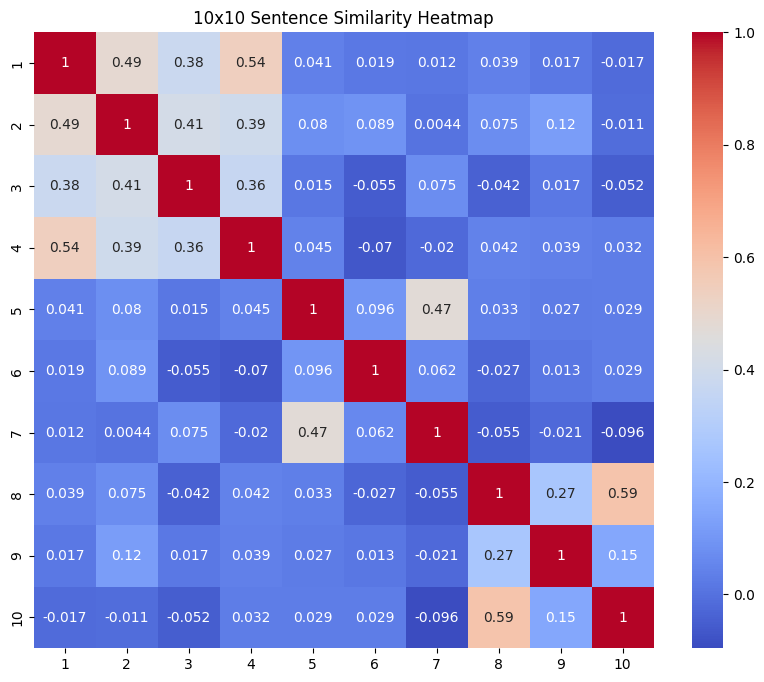

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="coolwarm",
    xticklabels=range(1,11),
    yticklabels=range(1,11)
)

plt.title("10x10 Sentence Similarity Heatmap")
plt.show()

In [12]:
import numpy as np

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(scores)[-2:][::-1]

print("Query sentence:")
print(query)
print("\nTop 2 most similar sentences:\n")

for i in top_indices:
    print(sentences[i])
    print("Similarity Score:", scores[i])
    print()

Query sentence:
The bowler took three wickets in one over

Top 2 most similar sentences:

The bowler delivered a fast yorker that shattered the stumps.
Similarity Score: 0.62511826

The batsman hit a brilliant cover drive for four runs.
Similarity Score: 0.55569416

